In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import time
import glob
from collections import Counter
from dotenv import load_dotenv
from openai import OpenAI

In [2]:
# Auto labeling PURE dataset
LABELING_MODEL = "gpt-4o-mini"

# Agent model for clarification
AGENT_MODEL = "gpt-5.1"

In [5]:
# Load PROMISE dataset
# Common column names are: 'RequirementText', 'class', or 'label'
def load_arff_as_df(filepath):
    data_rows = []
    attributes = []
    reading_data = False

    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            if line.lower().startswith('@attribute'):
                parts = line.split(None, 2)
                attributes.append(parts[1])
            elif line.lower().startswith('@data'):
                reading_data = True
            elif reading_data:
                row = []
                current = ''
                in_quotes = False
                for char in line:
                    if char == "'" and not in_quotes:
                        in_quotes = True
                    elif char == "'" and in_quotes:
                        in_quotes = False
                    elif char == ',' and not in_quotes:
                        row.append(current.strip().strip("'"))
                        current = ''
                    else:
                        current += char
                row.append(current.strip().strip("'"))
                if len(row) == len(attributes):
                    data_rows.append(row)

    return pd.DataFrame(data_rows, columns=attributes)


promise_df = load_arff_as_df('../data/raw/PROMISE/se-requirements-classification-master/0-datasets/PROMISE_exp/PROMISE_exp.arff')

print("Shape:", promise_df.shape)
print("\nColumns:", promise_df.columns.tolist())
print("\nLabel distribution:")
print(promise_df.iloc[:, -1].value_counts())
promise_df.head()

Shape: (969, 3)

Columns: ['ProjectID', 'RequirementText', '_class_']

Label distribution:
_class_
F     444
SE    125
US     85
O      77
PE     67
LF     49
A      31
MN     24
SC     22
FT     18
L      15
PO     12
Name: count, dtype: int64


,ProjectID,RequirementText,_class_
0,1,The system shall refresh the display every 60 ...,PE
1,1,The application shall match the color of the s...,LF
2,1,If projected the data must be readable. On a...,US
3,1,The product shall be available during normal b...,A
4,1,If projected the data must be understandable....,US


Using label column: _class_

Label distribution in PROMISE:
_class_
F     444
SE    125
US     85
O      77
PE     67
LF     49
A      31
MN     24
SC     22
FT     18
L      15
PO     12
Name: count, dtype: int64


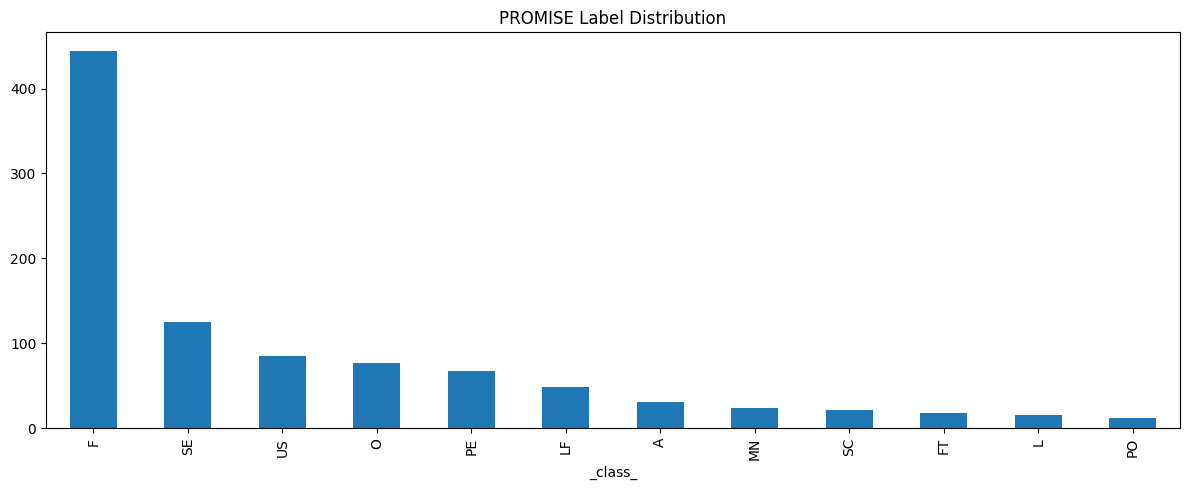

In [6]:
label_col = promise_df.columns[-1]
print("Using label column:", label_col)

print("\nLabel distribution in PROMISE:")
print(promise_df[label_col].value_counts())

# Visualize
promise_df[label_col].value_counts().plot(kind='bar', figsize=(12,5), title='PROMISE Label Distribution')
plt.tight_layout()
plt.show()

In [3]:
import xml.etree.ElementTree as ET
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
print("API key loaded:", api_key[:8] + "..." if api_key else "NOT FOUND - check .env file")

client = OpenAI(api_key=api_key)

def clean_text_block(text):
    """Clean a raw XML text block before sentence splitting."""
    if not text:
        return ""
    text = re.sub(r'\s+', ' ', text)          # collapse all whitespace/newlines
    text = re.sub(r'[^\x00-\x7F]+', ' ', text) # remove non-ASCII characters
    return text.strip()

def strip_leading_id(sentence):
    """
    Strip leading requirement IDs or list markers before validation.
    Handles formats like: [SSS004], [REQ-01], 1., (a), (I), 1.2.3
    Returns the cleaned sentence, or the original if nothing was stripped.
    """
    cleaned = re.sub(
        r'^(\[[\w\-]+\]|\([\w]+\)|\d+(\.\d+)*\.?)\s*',
        '', sentence
    ).strip()
    # Only return the stripped version if something meaningful remains
    return cleaned if len(cleaned) > 0 else sentence

def is_valid_sentence(sentence):
    """
    Filter out structurally bad sentences.
    Verb checking is intentionally removed — let the LLM decide
    what is and isn't a requirement during labeling.
    """
    sentence = sentence.strip()

    # Too short to be a meaningful requirement
    if len(sentence) < 30:
        return False

    # Strip leading IDs/list numbers, then check if it starts with lowercase
    stripped = strip_leading_id(sentence)
    if stripped and stripped[0].islower():
        return False

    # Ends with colon — broken list header (e.g. "The system shall support:")
    if sentence.endswith(':'):
        return False

    return True

def extract_sentences_from_xml(filepath):
    sentences = []
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()

        # Strip XML namespace from all tags
        for elem in root.iter():
            elem.tag = re.sub(r'\{.*?\}', '', elem.tag)

        for elem in root.iter('text_body'):
            if elem.text:
                cleaned = clean_text_block(elem.text)
                if not cleaned:
                    continue

                # Use NLTK for smart sentence splitting (handles abbreviations)
                split_sentences = sent_tokenize(cleaned)

                for sent in split_sentences:
                    sent = sent.strip()
                    if is_valid_sentence(sent):
                        sentences.append(sent)

    except Exception as e:
        print(f"Error parsing {filepath}: {e}")

    return sentences

# Testing before running on the full dataset
# test_file = '../data/raw/PURE/1414117/requirements-xml/XMLZIPFile/2003 - qheadache.xml'
# test_sentences = extract_sentences_from_xml(test_file)
# print(f"Found {len(test_sentences)} valid sentences")
# print("\nSample:")
# for s in test_sentences[:5]:
#     print(f"  - {s}")

def auto_label_requirement(sentence):
    """
    Label a single requirement sentence using GPT.
    Uses explicit prompt instructions to enforce raw label output only.
    Falls back to NFR_Other if an unexpected label is returned.
    """

    valid_labels = [
        'FR', 'NFR_Performance', 'NFR_Security', 'NFR_Usability',
        'NFR_Reliability', 'NFR_Maintainability', 'NFR_Scalability',
        'NFR_Portability', 'NFR_Operational', 'NFR_Legal',
        'NFR_LookAndFeel', 'NFR_Other', 'NOT_REQUIREMENT'
    ]

    # Format valid labels clearly for the prompt
    labels_str = ', '.join(valid_labels)

    prompt = f"""You are a requirements engineering expert.

Classify the sentence below into EXACTLY ONE label from this list:
{labels_str}

Label definitions:
- FR: describes what the system shall do (features, functions, behaviors)
- NFR_Performance: speed, response time, throughput, latency
- NFR_Security: authentication, encryption, access control, privacy
- NFR_Usability: ease of use, learnability, accessibility, user interface
- NFR_Reliability: availability, fault tolerance, recovery, uptime
- NFR_Maintainability: modularity, testability, extensibility, code quality
- NFR_Scalability: capacity, load handling, growth, concurrency
- NFR_Portability: platform compatibility, browser support, OS independence
- NFR_Operational: deployment, infrastructure, environment, monitoring
- NFR_Legal: compliance, regulations, licensing, standards
- NFR_LookAndFeel: visual design, branding, color schemes, layout style
- NFR_Other: non-functional requirement that does not fit any above category
- NOT_REQUIREMENT: introductory text, definitions, headings, background descriptions

OUTPUT RULES — you must follow these exactly:
1. Reply with ONLY the label string (e.g. FR or NFR_Security)
2. Do NOT include markdown formatting, backticks, or code blocks
3. Do NOT add any explanation, punctuation, or extra words
4. Do NOT invent labels outside the list above

Sentence: "{sentence}"
"""

    try:
        response = client.chat.completions.create(
            model=LABELING_MODEL,
            messages=[
                {
                    "role": "system",
                    "content": "You are a classification engine. You output only a single label string and nothing else."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            max_tokens=20,
            temperature=0
        )

        label = response.choices[0].message.content.strip()

        # Strip any accidental markdown backticks
        label = label.replace('`', '').strip()

        # Validate — reject anything outside the known label set
        if label not in valid_labels:
            print(f"Unexpected label '{label}' for: {sentence[:60]}... → defaulting to NFR_Other")
            return 'NFR_Other'

        return label

    except Exception as e:
        print(f"API error: {e} — retrying in 3s...")
        time.sleep(3)
        return 'NFR_Other'

API key loaded: sk-proj-...


In [ ]:
xml_folder = '../data/raw/PURE/1414117/requirements-xml/XMLZIPFile/'
all_rows = []

xml_files = glob.glob(os.path.join(xml_folder, '*.xml'))
print(f"Found {len(xml_files)} XML files\n")

for xml_file in xml_files:
    doc_name = os.path.basename(xml_file)
    sentences = extract_sentences_from_xml(xml_file)
    
    print(f"Processing: {doc_name} ({len(sentences)} sentences)...")
    
    for sentence in sentences:
        label = auto_label_requirement(sentence)
        all_rows.append({
            'text': sentence,
            'label': label,
            'source': 'PURE',
            'document': doc_name
        })
        time.sleep(0.1)  # avoid rate limiting
    
    print(f"Done: {doc_name}")

# --- Build dataframe ---
pure_df = pd.DataFrame(all_rows)
print(f"\nTotal rows before cleaning: {len(pure_df)}")
print(f"\nRaw label distribution:\n{pure_df['label'].value_counts()}")

# --- Apply Cell 3 cleaning inline ---
# Fix whitespace
pure_df['text'] = pure_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Remove fragments
pure_df = pure_df[pure_df['text'].str.match(r'^[\[\("\'\d]*[A-Z]')]

# Remove too short
pure_df = pure_df[pure_df['text'].str.len() >= 30]

# Remove duplicates
pure_df = pure_df.drop_duplicates(subset=['text'])

# Remove NOT_REQUIREMENT
not_req_count = (pure_df['label'] == 'NOT_REQUIREMENT').sum()
print(f"\nRemoving {not_req_count} NOT_REQUIREMENT rows...")
pure_df = pure_df[pure_df['label'] != 'NOT_REQUIREMENT']

# Keep only valid labels
valid_labels = [
    'FR', 'NFR_Performance', 'NFR_Security', 'NFR_Usability',
    'NFR_Reliability', 'NFR_Maintainability', 'NFR_Scalability',
    'NFR_Portability', 'NFR_Operational', 'NFR_Legal',
    'NFR_LookAndFeel', 'NFR_Other'
]
pure_df = pure_df[pure_df['label'].isin(valid_labels)]

# --- Final report ---
print(f"\nFinal rows after cleaning: {len(pure_df)}")
print(f"\nFinal label distribution:\n{pure_df['label'].value_counts()}")

# --- Save ---
pure_df.to_csv('../data/processed/pure_autolabeled.csv', index=False)
print("\nSaved pure_autolabeled.csv")

Found 18 XML files

Processing: 0000 - cctns.xml (197 sentences)...
Done: 0000 - cctns.xml
Processing: 0000 - gamma j.xml (180 sentences)...
Done: 0000 - gamma j.xml
Processing: 1995 - gemini.xml (547 sentences)...
Done: 1995 - gemini.xml
Processing: 1998 - themas.xml (177 sentences)...
Done: 1998 - themas.xml
Processing: 1999 - dii.xml (51 sentences)...
Done: 1999 - dii.xml
Processing: 1999 - tcs.xml (617 sentences)...
Done: 1999 - tcs.xml
Processing: 2003 - qheadache.xml (103 sentences)...
Done: 2003 - qheadache.xml
Processing: 2005 - microcare.xml (135 sentences)...
Done: 2005 - microcare.xml
Processing: 2005 - phin.xml (184 sentences)...
Done: 2005 - phin.xml
Processing: 2006 - eirene sys 15.xml (578 sentences)...
Done: 2006 - eirene sys 15.xml
Processing: 2007 - get real 0.2.xml (102 sentences)...
Done: 2007 - get real 0.2.xml
Processing: 2007-eirene_fun_7-2.xml (687 sentences)...
Done: 2007-eirene_fun_7-2.xml
Processing: 2007-ertms.xml (204 sentences)...
Done: 2007-ertms.xml
Proc

In [ ]:
# pure_autolabeled.csv cleaning and fixes

pure_df = pd.read_csv('../data/processed/pure_autolabeled.csv')
print(f"Starting rows: {len(pure_df)}\n")

# ── Fix 1: Strip trailing (e.g. and (i.e. instead of dropping ────────────
def clean_trailing_eg(text):
    text = re.sub(r'\s*\(?\b(?:e\.g\.?|i\.e\.?)\s*$', '.', text.strip())
    return text.strip()

pure_df['text'] = pure_df['text'].apply(clean_trailing_eg)
print(f"Fix 1 done — trailing (e.g./(i.e. cleaned")

# ── Fix 2: Split merged sentences instead of removing ────────────────────
def split_merged_sentences(pure_df):
    new_rows = []
    split_count = 0

    for _, row in pure_df.iterrows():
        text = row['text']

        if re.search(r'\.[A-Z][a-z]', text):
            spaced = re.sub(r'\.([A-Z])', r'. \1', text)
            parts = sent_tokenize(spaced)

            if len(parts) > 1:
                split_count += 1
                for part in parts:
                    part = part.strip()
                    if len(part) >= 30:
                        new_rows.append({
                            'text'    : part,
                            'label'   : row['label'],
                            'source'  : row['source'],
                            'document': row['document']
                        })
                continue

        new_rows.append(row.to_dict())

    print(f"Fix 2 done — split {split_count} merged rows")
    return pd.DataFrame(new_rows).reset_index(drop=True)

pure_df = split_merged_sentences(pure_df)

# ── Fix 3: Drop very long list-style sentences (>400 chars) ──────────────
long_mask = pure_df['text'].str.len() > 400
print(f"Fix 3: Removing {long_mask.sum()} overly long list sentences")
pure_df = pure_df[~long_mask]

# ── Fix 4: Comprehensive Reference ID Stripping & Final Dedup ─────────────
def clean_reference_ids(text):
    text = str(text)
    
    # 1. Remove leading IDs (e.g., "[SSS004] ", "(1) ", "(REQ-1) ")
    text = re.sub(r'^([\[\(][\w\-\.]+[\]\)]\s*)+', '', text)
    
    # 2. Remove internal/bracketed IDs anywhere else in the text (e.g., "[SSS211]")
    text = re.sub(r'\s*\[[\w\-]+\]\s*', ' ', text)
    
    # 3. Remove trailing document references (e.g., "see 5.2.3.26" or "as shown in 3.2-1")
    text = re.sub(r'\s*(see|as shown in|refer to|defined in)\s+[\d\.\-]+\w*\.?\s*$', '.', text, flags=re.IGNORECASE)
    
    # 4. Clean up any extra spaces left behind by the removals
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. Clean up awkward punctuation caused by the removals (e.g., "word : ." becomes "word.")
    text = re.sub(r':\s*\.', '.', text)
    text = re.sub(r'\.\s*\.', '.', text)
    
    return text

# Apply the combined cleaning function
pure_df['text'] = pure_df['text'].apply(clean_reference_ids)

# Drop rows ending in a colon, or a colon followed by list tags like (M), (I), (O), etc.
pure_df = pure_df[~pure_df['text'].str.contains(r':\s*(?:\([A-Z]\))?\s*$', regex=True, na=False)]

# Drop sentences that became too short after IDs were stripped, then deduplicate
pure_df = pure_df[pure_df['text'].str.len() >= 30]
pure_df = pure_df.drop_duplicates(subset=['text']).reset_index(drop=True)

print(f"Fix 4: Stripped all reference IDs, removed orphaned list headers and deduplicated data (Final rows: {len(pure_df)})")

# ── Fix 5: GPT validation on short suspicious sentences only ─────────────
def is_valid_requirement_gpt(text):
    prompt = f"""You are a requirements engineering expert.
Is the following sentence a software requirement (functional or non-functional)?
Or is it a document heading, section title, artifact, or background description?

Sentence: "{text}"

Reply with ONLY one word: YES if it is a real requirement, NO if it is not."""
    try:
        response = client.chat.completions.create(
            model=LABELING_MODEL,
            messages=[
                {"role": "system", "content": "You are a binary classifier. Reply only YES or NO."},
                {"role": "user",   "content": prompt}
            ],
            max_tokens=5,
            temperature=0
        )
        return response.choices[0].message.content.strip().upper() == 'YES'
    except:
        return True  # keep on API failure

suspicious_mask = (
    (pure_df['text'].str.len() < 60) &
    (~pure_df['text'].str.contains(
        r'shall|must|should|will|can|able|provide|support|allow|enable|ensure',
        case=False, regex=True, na=False
    ))
)
suspicious_df = pure_df[suspicious_mask]
print(f"\nChecking {len(suspicious_df)} suspicious sentences with GPT...")

rows_to_drop = []
for idx, row in suspicious_df.iterrows():
    if not is_valid_requirement_gpt(row['text']):
        rows_to_drop.append(idx)
    time.sleep(0.1)

pure_df = pure_df.drop(index=rows_to_drop).reset_index(drop=True)
print(f"Fix 5 done — GPT removed {len(rows_to_drop)} non-requirements")

# ── Fix 6: Re-label suspicious NFR_Legal rows with GPT ───────────────────
legal_df = pure_df[pure_df['label'] == 'NFR_Legal']
legal_keywords = r'\bcompl(y|iance|iant)\b|\bregulat|\bstandard\b|\blicense|\blaw\b|\blegal|\bGDPR|\bISO\b|\bIEEE\b|\bcertif|\bstatut|\bpolic'
suspicious_legal = legal_df[
    ~legal_df['text'].str.contains(legal_keywords, case=False, regex=True, na=False)
]
print(f"\nRe-labeling {len(suspicious_legal)} suspicious NFR_Legal rows with GPT...")

for idx, row in suspicious_legal.iterrows():
    new_label = auto_label_requirement(row['text'])
    pure_df.at[idx, 'label'] = new_label
    time.sleep(0.1)

print(f"\nFix 6: Re-labeling complete")
print(f"New NFR_Legal count: {(pure_df['label'] == 'NFR_Legal').sum()}")

# ── Final report ──────────────────────────────────────────────────────────
print(f"\nFinal rows: {len(pure_df)}")
print(f"\nFinal label distribution:")
print(pure_df['label'].value_counts())

pure_df.to_csv('../data/processed/pure_autolabeled_clean.csv', index=False)
print("\nSaved pure_autolabeled_clean.csv")

Starting rows: 3023

Fix 1 done — trailing (e.g./(i.e. cleaned
Fix 2 done — split 5 merged rows
Fix 3: Removing 12 overly long list sentences
Fix 4: Stripped all reference IDs, removed orphaned list headers and deduplicated data (Final rows: 2962)

Checking 141 suspicious sentences with GPT...
Fix 5 done — GPT removed 57 non-requirements

Re-labeling 113 suspicious NFR_Legal rows with GPT...


C:\Users\alan\AppData\Local\Temp\ipykernel_42092\3954806187.py:131: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~legal_df['text'].str.contains(legal_keywords, case=False, regex=True, na=False)



Fix 6: Re-labeling complete
New NFR_Legal count: 234

Final rows: 2905

Final label distribution:
label
FR                     1815
NFR_Legal               234
NFR_Usability           175
NFR_Security            155
NFR_Operational         111
NFR_Reliability          91
NFR_Performance          81
NFR_Other                72
NFR_Maintainability      62
NFR_Portability          53
NFR_Scalability          33
NFR_LookAndFeel          19
NOT_REQUIREMENT           4
Name: count, dtype: int64

Saved pure_autolabeled_clean.csv


In [ ]:
# Remove user action / use case step patterns that describe what a USER does, not what the SYSTEM shall do.
def is_user_action(text):
    """
    Detect user action / use case step patterns.
    These describe what a USER does, not what the SYSTEM shall do.
    """
    text = text.strip()

    # Pattern 1: Starts with a role/actor performing an action
    # e.g. "Customer clicks...", "Administrator selects..."
    actor_action = re.compile(
        r'^(Customer|User|Admin(istrator)?|Sales Person|Operator|Manager|Guest|'
        r'Supervisor|Developer|Staff|Client)\s+'
        r'(clicks?|selects?|removes?|enters?|types?|fills?|submits?|opens?|'
        r'closes?|logs?\s*(in|out)|navigates?|uploads?|downloads?|'
        r'chooses?|drags?|drops?|presses?|accesses?)',
        re.IGNORECASE
    )
    if actor_action.match(text):
        return True

    # Pattern 2: Imperative verb targeting a user task (no system subject)
    # e.g. "Login to...", "Register a new...", "Install a plug-in..."
    # Key: no "system", "shall", "must", "should" anywhere in sentence
    imperative_verbs = re.compile(
        r'^(Login|Logout|Log\s+in|Log\s+out|Register|Install|Uninstall|'
        r'Navigate|Click|Select|Remove|Enter|Submit|Upload|Download|Open|Close|'
        r'Remove|Add|Create|Delete|Edit|Update|View|Search|Filter|Sort|'
        r'Access|Configure|Enable|Disable|Reset|Change|Set)',
        re.IGNORECASE
    )
    has_system_subject = re.compile(
        r'\b(system|shall|must|should|application|software|module|platform)\b',
        re.IGNORECASE
    )
    if imperative_verbs.match(text) and not has_system_subject.search(text):
        return True

    # Pattern 3: Passive user state description (no system obligation)
    # e.g. "The Customer is logged out of the system."
    passive_user_state = re.compile(
        r'^The\s+(Customer|User|Admin(istrator)?|Sales Person|Operator|Manager|Guest|'
        r'Supervisor|Developer|Staff|Client)\s+(is|are|has|have|was|were)',
        re.IGNORECASE
    )
    if passive_user_state.match(text):
        return True

    return False

# --- Apply and report ---
user_action_mask = pure_df['text'].apply(is_user_action)
print(f"User actions / use case steps found: {user_action_mask.sum()}")
print("\nDetected rows:")
for t in pure_df[user_action_mask]['text'].head(user_action_mask.sum()).tolist():
    print(f"  - {t}")

User actions / use case steps found: 42

Detected rows:
  - Opening new windows can distract, confuse or impede users for a variety of reasons.
  - Customer clicks button or link to "Register"
  - Customer clicks button or link to "Login"
  - Edit the customer account details.
  - Customer clicks on the button or link to "Edit Account"
  - Customer clicks on the button or link to "Logout"
  - The Customer is logged out of the system.
  - Customer clicks the button or link to "Add To Cart".
  - Customer clicks button or link to "Ckeckout"
  - Administrator clicks button or link to "Login"
  - Administrator clicks button or link to "Logout"
  - Administrator clicks button or link to "Add Users"
  - Administrator clicks button or link to Remove User"
  - Administrator clicks button or link to Change User Properties"
  - Administrator clicks the button or link to "Install Plug-ins "
  - Administrator clicks the button or link to "Install Plug-ins"
  - Administrator clicks button or link to

In [ ]:
# Confirm the detected rows look right before dropping
print(f"\nRows before: {len(pure_df)}")
pure_df = pure_df[~user_action_mask].reset_index(drop=True)
print(f"Rows after removing user actions: {len(pure_df)}")

pure_df.to_csv('../data/processed/pure_autolabeled_clean.csv', index=False)
print("Saved pure_autolabeled_clean.csv")


Rows before: 2905
Rows after removing user actions: 2863
Saved pure_autolabeled_clean.csv


In [9]:
# SymSpell for OCR broken words fix
from symspellpy import SymSpell, Verbosity
import pkg_resources

# Initialize SymSpell once globally
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
dictionary_path = pkg_resources.resource_filename(
    "symspellpy", "frequency_dictionary_en_82_765.txt"
)
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)

# All ligature types to try — ordered from most to least common in PDFs
LIGATURES = ['fi', 'fl', 'ff', 'ffi', 'ffl', 'ft', 'st']

# Words too short to be valid OCR prefixes — skip merging these
SKIP_WORDS = {
    'a', 'an', 'as', 'at', 'be', 'by', 'do', 'go', 'he', 'if',
    'in', 'is', 'it', 'me', 'my', 'no', 'of', 'on', 'or', 'so',
    'to', 'up', 'us', 'we', 'all', 'and', 'are', 'but', 'can',
    'for', 'has', 'had', 'his', 'how', 'its', 'may', 'not', 'now',
    'one', 'our', 'out', 'own', 'per', 'set', 'she', 'the', 'too',
    'two', 'use', 'was', 'who', 'why', 'yet', 'you', 'any', 'also',
    'data', 'each', 'from', 'have', 'into', 'just', 'more', 'most',
    'must', 'only', 'over', 'shall', 'should', 'such', 'than', 'that',
    'them', 'then', 'they', 'this', 'used', 'user', 'very', 'well',
    'were', 'when', 'will', 'with', 'both', 'been', 'their', 'there',
    'these', 'would', 'could', 'which', 'while', 'where',
}

# Words that are valid English BUT are also known OCR fragment prefixes
# Merging is still attempted for these even though they pass is_valid_word()
OCR_FRAGMENT_PREFIXES = {
    # Common prefixes that appear before ligature or column breaks
    'pro', 'con', 'pre', 'de', 're',
    # Longer OCR-specific prefixes from column/hyphen breaks
    'recon', 'speci', 'noti', 'certi', 'signi',
    'classi', 'identi', 'modi', 'veri', 'ampli',
    'magni', 'quali', 'justi', 'suf', 'dif',
    'inde', 'cali', 'recti', 'satis', 'clari',
    'uni', 'multi', 'over', 'under', 'inter',
}

def split_word_and_punct(word):
    """Split a token into (leading_punct, core_word, trailing_punct)"""
    match = re.match(r'^([^a-zA-Z]*)([a-zA-Z]*)([^a-zA-Z]*)$', word)
    if match:
        return match.group(1), match.group(2), match.group(3)
    return '', word, ''

def is_valid_word(word):
    """Check if a word exists in SymSpell dictionary (exact match only)"""
    results = sym_spell.lookup(word.lower(), Verbosity.CLOSEST, max_edit_distance=0)
    return len(results) > 0 and results[0].term == word.lower()

def try_fix_pair(part1, part2):
    """
    Try all strategies to merge two potential OCR fragments.
    Returns fixed word string or None if no fix found.
    
    Strategy 1: Direct merge (handles column/hyphen breaks)
    Strategy 2: Ligature insertion (handles fi/fl/ff/ffi/ffl breaks)
    """
    if not part1 or not part2:
        return None

    p1 = part1.lower()
    p2 = part2.lower()

    # ── Skip if either part contains digits or special chars ──
    # Prevents "8m" + "Telescopes" → "8telescopes"
    # Prevents "V1" + ".0" or version numbers being mangled
    if re.search(r'\d', p1) or re.search(r'\d', p2):
        return None
    
    # ── Skip if either part contains non-alphabetic chars ──
    if not p1.isalpha() or not p2.isalpha():
        return None

    # Skip if either part is a common valid word — not an OCR fragment
    if p1 in SKIP_WORDS or p2 in SKIP_WORDS:
        return None

    # ── KEY LOGIC ──────────────────────────────────────────────────────
    # If p1 is a valid word AND is NOT a known OCR prefix → skip merging
    # This blocks: "short pages", "key role", "home page" false positives
    #
    # If p1 is a valid word BUT IS a known OCR prefix → still attempt merge
    # This allows: "pro le" → "profile", "recon gure" → "reconfigure"
    #
    # If p1 is NOT a valid word → always attempt merge
    # This allows: "ef cient" → "efficient", "speci c" → "specific"
    # ───────────────────────────────────────────────────────────────────
    if is_valid_word(p1) and p1 not in OCR_FRAGMENT_PREFIXES:
        return None

    def get_frequency(word):
        """Get word frequency from SymSpell dictionary — higher = more common"""
        results = sym_spell.lookup(word.lower(), Verbosity.CLOSEST, max_edit_distance=0)
        if results and results[0].term == word.lower():
            return results[0].count
        return 0
    
    # ── Collect ALL valid candidates instead of returning the first one ──
    candidates = []  # list of (word, frequency)

    # --- Strategy 1: Direct merge (column break, no missing chars) ---
    # e.g. "speci" + "c" → "specific", "recon" + "gure" → "reconfigure"
    direct_merge = p1 + p2
    if is_valid_word(direct_merge):
        candidates.append((direct_merge, get_frequency(direct_merge)))

    # --- Strategy 2: Ligature insertion ---
    # e.g. "ef" + "cient" → try "ef" + "fi" + "cient" = "efficient"
    for ligature in LIGATURES:
        candidate = p1 + ligature + p2
        if is_valid_word(candidate):
            candidates.append((candidate, get_frequency(candidate)))

    # --- Strategy 3: SymSpell fuzzy match on direct merge ---
    # Catches cases where direct merge is almost right but needs 1-2 corrections
    # Only use distance=1 to avoid over-correction
    if len(direct_merge) >= 8:  # skip very short merges — too risky
        suggestions = sym_spell.lookup(
            direct_merge, Verbosity.CLOSEST, max_edit_distance=1
        )
        if suggestions and suggestions[0].distance <= 1:
            candidates.append((suggestions[0].term, suggestions[0].count))

    if not candidates:
        return None
    
    # ── Pick the most frequently used word across all candidates ──
    # "profile" (very common) will always beat "prole" (very rare)
    best_word = max(candidates, key=lambda x: x[1])[0]
    return best_word

def fix_ocr_symspell_hybrid(text):
    tokens = text.split()
    fixed_tokens = []
    i = 0

    while i < len(tokens):
        token = tokens[i]
        lead, word, trail = split_word_and_punct(token)

        # ── Guard: skip merging if current OR next raw token contains digits ──
        # Must check BEFORE split_word_and_punct strips them
        # Catches: "8m", "V1.0", "99.9%", "Phase2", "C4I"
        current_has_digit = bool(re.search(r'\d', token))
        next_has_digit = (
            bool(re.search(r'\d', tokens[i + 1])) 
            if i < len(tokens) - 1 
            else False
        )

        if word and not current_has_digit and not next_has_digit and i < len(tokens) - 1:
            next_token = tokens[i + 1]
            next_lead, next_word, next_trail = split_word_and_punct(next_token)

            fixed = try_fix_pair(word, next_word)
            if fixed:
                # Restore capitalization if original started with uppercase
                if word[0].isupper():
                    fixed = fixed.capitalize()
                fixed_tokens.append(lead + fixed + next_trail)
                i += 2
                continue

        fixed_tokens.append(token)
        i += 1

    return ' '.join(fixed_tokens)

# --- Test all four OCR categories ---
test_cases = [
    # Category 1: fi/fl ligature breaks
    ("ef cient use of the system",           "efficient use of the system"),
    ("pro le settings for the user",          "profile settings for the user"),
    ("dif cult to maintain",                  "difficult to maintain"),
    # Category 2: Column/hyphenation breaks (most common in your data)
    ("speci c requirements for the module",   "specific requirements for the module"),
    ("recon gure the system after failure",   "reconfigure the system after failure"),
    ("noti cation must be sent to users",     "notification must be sent to users"),
    ("certi cate must be validated",          "certificate must be validated"),
    # Category 3: Mixed sentence
    ("maximizing ef cient and speci c use",   "maximizing efficient and specific use"),
    # False positive tests — must NOT be changed
    ("short pages are more appropriate",     "short pages are more appropriate"),
    ("key role in accessibility",            "key role in accessibility"),
    # NEW: Digit/version number guards — must NOT change
    ("Gemini 8m Telescopes operations",                    "Gemini 8m Telescopes operations"),
    ("CCTNS V1.0 functionality is designed",               "CCTNS V1.0 functionality is designed"),
    ("system shall have availability of 99.9 percent",     "system shall have availability of 99.9 percent"),
    ("system shall have 99.9% availability",             "system shall have 99.9% availability"),
]

print("=== TEST RESULTS ===\n")
all_passed = True
for input_text, expected in test_cases:
    result = fix_ocr_symspell_hybrid(input_text)
    passed = result.lower() == expected.lower()
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"{status}")
    print(f"  Input:    {input_text}")
    print(f"  Expected: {expected}")
    print(f"  Result:   {result}\n")

print("All tests passed!" if all_passed else "Some tests failed — review above")

=== TEST RESULTS ===

PASS
  Input:    ef cient use of the system
  Expected: efficient use of the system
  Result:   efficient use of the system

PASS
  Input:    pro le settings for the user
  Expected: profile settings for the user
  Result:   profile settings for the user

PASS
  Input:    dif cult to maintain
  Expected: difficult to maintain
  Result:   difficult to maintain

PASS
  Input:    speci c requirements for the module
  Expected: specific requirements for the module
  Result:   specific requirements for the module

PASS
  Input:    recon gure the system after failure
  Expected: reconfigure the system after failure
  Result:   reconfigure the system after failure

PASS
  Input:    noti cation must be sent to users
  Expected: notification must be sent to users
  Result:   notification must be sent to users

PASS
  Input:    certi cate must be validated
  Expected: certificate must be validated
  Result:   certificate must be validated

PASS
  Input:    maximizing ef cie

In [11]:
# Apply the OCR fix to the entire dataset and report changes

# Load the cleaned CSV
pure_df = pd.read_csv('../data/processed/pure_autolabeled_clean.csv')
print(f"Rows before OCR fix: {len(pure_df)}")

before = pure_df['text'].copy()

# Apply the OCR fix
pure_df['text'] = pure_df['text'].apply(fix_ocr_symspell_hybrid)

# Report what changed
changed_mask = pure_df['text'] != before
print(f"Rows with OCR fixes applied: {changed_mask.sum()}")

# Show sample fixes for manual verification
print("\nSample fixes:")
sample_changes = pure_df[changed_mask][['text']].copy()
sample_changes['before'] = before[changed_mask]
for _, row in sample_changes.head(10).iterrows():
    print(f"  Before: {row['before'][:200]}")
    print(f"  After:  {row['text'][:200]}")
    print()

# Save
pure_df.to_csv('../data/processed/pure_autolabeled_clean.csv', index=False)
print("OCR fixes applied and saved to pure_autolabeled_clean.csv")

Rows before OCR fix: 2863
Rows with OCR fixes applied: 0

Sample fixes:
OCR fixes applied and saved to pure_autolabeled_clean.csv


In [14]:
fr_nfr_df = pd.read_excel('../data/raw/FR_NFR/FR_NFR_Dataset.xlsx')

print("Shape:", fr_nfr_df.shape)
print("\nColumns:", fr_nfr_df.columns.tolist())
print("\nLabel distribution:")
print(fr_nfr_df.iloc[:, -1].value_counts())
fr_nfr_df.head()

Shape: (6117, 2)

Columns: ['Requirement Text', 'Type']

Label distribution:
Type
FR     3964
NFR    2122
Name: count, dtype: int64


,Requirement Text,Type
0,The app shall run on a smart phone with Androi...,NFR
1,All layout shall be according to the TU/e corp...,NFR
2,The icons shall be according to the Android Ic...,NFR
3,The user interfaces shall be according to the ...,NFR
4,"The Twitter ""tweet"" interface shall be accordi...",NFR


In [16]:
# ---- Standardize PROMISE ----
# Typical PROMISE columns: 'RequirementText', 'class'
promise_clean = pd.DataFrame({
    'text': promise_df['RequirementText'],  # change if your column name differs
    'label': promise_df['_class_'],           # change if your column name differs
    'source': 'PROMISE'
})

# ---- Standardize PURE ----
# Typical PURE columns may vary — inspect yours and adjust
pure_clean = pd.DataFrame({
    'text': pure_df['text'],          # adjust
    'label': pure_df['label'],        # adjust  
    'source': 'PURE'
})

# ---- Standardize FR_NFR ----
fr_nfr_clean = pd.DataFrame({
    'text': fr_nfr_df['Requirement Text'],   # adjust
    'label': fr_nfr_df['Type'],  # adjust
    'source': 'FR_NFR'
})

print("PROMISE labels:", promise_clean['label'].unique())
print("PURE labels:", pure_clean['label'].unique())
print("FR_NFR labels:", fr_nfr_clean['label'].unique())

PROMISE labels: ['PE' 'LF' 'US' 'A' 'SE' 'F' 'FT' 'SC' 'PO' 'O' 'L' 'MN']
PURE labels: ['FR' 'NFR_Performance' 'NFR_Usability' 'NFR_Reliability' 'NFR_Security'
 'NFR_Legal' 'NFR_LookAndFeel' 'NFR_Other' 'NFR_Scalability'
 'NFR_Maintainability' 'NFR_Operational' 'NFR_Portability'
 'NOT_REQUIREMENT']
FR_NFR labels: ['NFR' 'FR' nan]


In [18]:
# Define your master label mapping
# Look at the unique labels printed above and map them here
# ── PROMISE label mapping ─────────────────────────────────────────────────
promise_label_mapping = {
    'F'  : 'FR',
    'PE' : 'NFR_Performance',
    'LF' : 'NFR_LookAndFeel',
    'US' : 'NFR_Usability',
    'A'  : 'NFR_Reliability',      # Availability → merged into Reliability
    'SE' : 'NFR_Security',
    'FT' : 'NFR_Reliability',      # FaultTolerance → merged into Reliability
    'SC' : 'NFR_Scalability',
    'PO' : 'NFR_Portability',
    'O'  : 'NFR_Operational',
    'L'  : 'NFR_Legal',
    'MN' : 'NFR_Maintainability',
}

# ── FR_NFR label mapping ──────────────────────────────────────────────────
# FR_NFR is binary only — 'FR' and 'NFR'
# NFR has no subcategory info so maps to NFR_Other
fr_nfr_label_mapping = {
    'FR'  : 'FR',
    'NFR' : 'NFR_Other',
}

# ── Apply PROMISE mapping ─────────────────────────────────────────────────
promise_clean['label'] = promise_clean['label'].map(promise_label_mapping)
promise_clean.dropna(subset=['label'], inplace=True)
print(f"PROMISE after mapping: {len(promise_clean)} rows")
print(promise_clean['label'].value_counts())

# ── PURE — already correctly labeled, skip mapping ───────────────────────
print(f"\nPURE labels already clean: {len(pure_clean)} rows")
print(pure_clean['label'].value_counts())

# ── Apply FR_NFR mapping ──────────────────────────────────────────────────
fr_nfr_clean['label'] = fr_nfr_clean['label'].map(fr_nfr_label_mapping)
fr_nfr_clean.dropna(subset=['label'], inplace=True)  # drops nan rows
print(f"\nFR_NFR after mapping: {len(fr_nfr_clean)} rows")
print(fr_nfr_clean['label'].value_counts())

PROMISE after mapping: 969 rows
label
FR                     444
NFR_Security           125
NFR_Usability           85
NFR_Operational         77
NFR_Performance         67
NFR_LookAndFeel         49
NFR_Reliability         49
NFR_Maintainability     24
NFR_Scalability         22
NFR_Legal               15
NFR_Portability         12
Name: count, dtype: int64

PURE labels already clean: 2863 rows
label
FR                     1778
NFR_Legal               234
NFR_Usability           174
NFR_Security            153
NFR_Operational         110
NFR_Reliability          91
NFR_Performance          81
NFR_Other                71
NFR_Maintainability      62
NFR_Portability          53
NFR_Scalability          33
NFR_LookAndFeel          19
NOT_REQUIREMENT           4
Name: count, dtype: int64

FR_NFR after mapping: 6086 rows
label
FR           3964
NFR_Other    2122
Name: count, dtype: int64


In [19]:
# Merge all into one master dataframe
master_df = pd.concat([promise_clean, pure_clean, fr_nfr_clean], ignore_index=True)

print("Total records:", len(master_df))
print("\nLabel distribution:")
print(master_df['label'].value_counts())

master_df.sample(10)  # inspect random samples

Total records: 9918

Label distribution:
label
FR                     6186
NFR_Other              2193
NFR_Security            278
NFR_Usability           259
NFR_Legal               249
NFR_Operational         187
NFR_Performance         148
NFR_Reliability         140
NFR_Maintainability      86
NFR_LookAndFeel          68
NFR_Portability          65
NFR_Scalability          55
NOT_REQUIREMENT           4
Name: count, dtype: int64


,text,label,source
2134,The TCS HCI shall provide continuously-availab...,FR,PURE
1595,The trigger value is used in combination with ...,FR,PURE
6261,The user shall be able to add the date and tim...,FR,FR_NFR
6023,Employers and recruiters shall be able to crea...,FR,FR_NFR
2168,The TCS shall be rail transportable.,FR,PURE
6171,The system shall provide the functionality for...,FR,FR_NFR
1710,The TCS shall consist of the TCS workstation H...,FR,PURE
9730,System shall ensure correctness in displaying ...,NFR_Other,FR_NFR
9833,Workers shall be able to change their passwords.,FR,FR_NFR
6189,User shall be able to change profile settings ...,FR,FR_NFR


Removing 0 NOT_REQUIREMENT rows...
Removed 0 duplicate rows

After basic cleaning: 9553 rows
label
FR                     6016
NFR_Other              2002
NFR_Security            278
NFR_Usability           259
NFR_Legal               249
NFR_Operational         187
NFR_Performance         148
NFR_Reliability         140
NFR_Maintainability      86
NFR_LookAndFeel          68
NFR_Portability          65
NFR_Scalability          55
Name: count, dtype: int64
  Oversampled  NFR_Performance: 148 → 200
  Oversampled  NFR_LookAndFeel: 68 → 200
  Kept as-is   NFR_Usability: 259
  Oversampled  NFR_Reliability: 140 → 200
  Kept as-is   NFR_Security: 278
  Undersampled FR: 6016 → 2000
  Oversampled  NFR_Scalability: 55 → 200
  Oversampled  NFR_Portability: 65 → 200
  Oversampled  NFR_Operational: 187 → 200
  Kept as-is   NFR_Legal: 249
  Oversampled  NFR_Maintainability: 86 → 200
  Undersampled NFR_Other: 2002 → 2000

BEFORE balancing: 9553 rows
AFTER  balancing: 6186 rows

Final label distribut

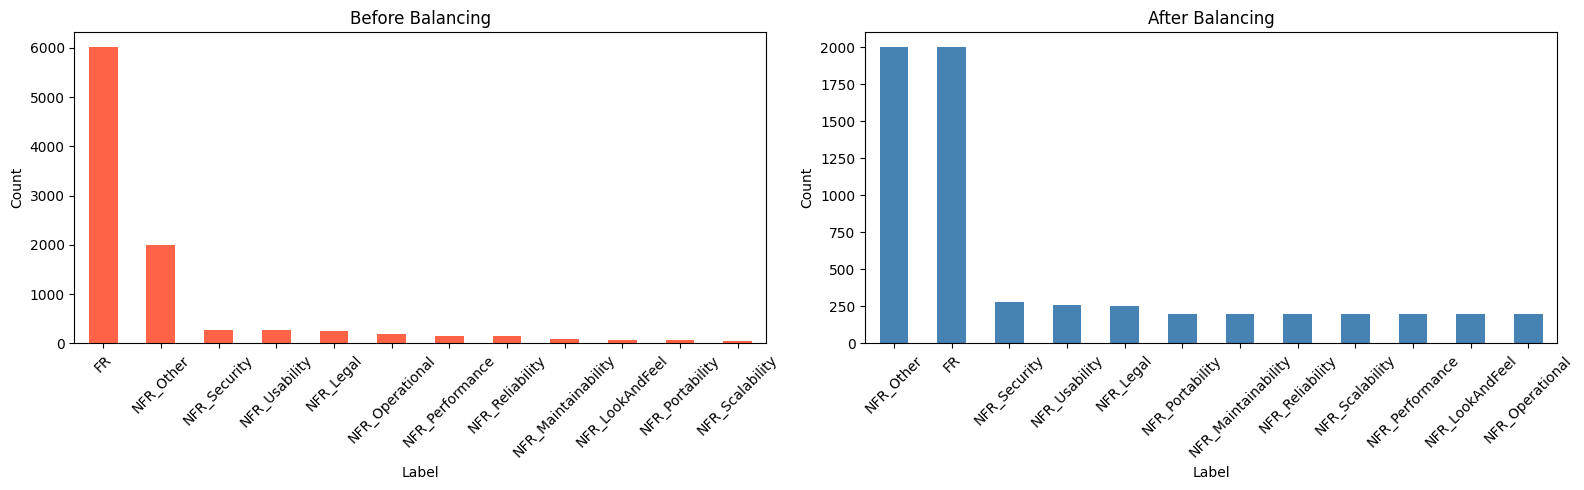


Saved master_dataset.csv (original)
Saved master_dataset_balanced.csv (balanced — use this for training)


In [21]:
# Final Fixing & Balancing Steps
# ── Fix 1: Remove NOT_REQUIREMENT rows ───────────────────────────────────
not_req = (master_df['label'] == 'NOT_REQUIREMENT').sum()
print(f"Removing {not_req} NOT_REQUIREMENT rows...")
master_df = master_df[master_df['label'] != 'NOT_REQUIREMENT'].reset_index(drop=True)

# ── Fix 2: Remove duplicates across datasets ─────────────────────────────
before_dedup = len(master_df)
master_df = master_df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"Removed {before_dedup - len(master_df)} duplicate rows")

print(f"\nAfter basic cleaning: {len(master_df)} rows")
print(master_df['label'].value_counts())

# ── Fix 3: Address class imbalance with oversampling + capping ───────────
from sklearn.utils import resample

# Define min and max samples per class
MIN_SAMPLES = 200   # oversample any class below this
MAX_SAMPLES = 2000  # cap any class above this

balanced_dfs = []

for label in master_df['label'].unique():
    class_df = master_df[master_df['label'] == label]
    n = len(class_df)

    if n < MIN_SAMPLES:
        # Oversample minority classes with replacement
        class_df = resample(
            class_df,
            replace=True,
            n_samples=MIN_SAMPLES,
            random_state=42
        )
        print(f"  Oversampled  {label}: {n} → {MIN_SAMPLES}")

    elif n > MAX_SAMPLES:
        # Undersample majority classes without replacement
        class_df = resample(
            class_df,
            replace=False,
            n_samples=MAX_SAMPLES,
            random_state=42
        )
        print(f"  Undersampled {label}: {n} → {MAX_SAMPLES}")

    else:
        print(f"  Kept as-is   {label}: {n}")

    balanced_dfs.append(class_df)

master_balanced_df = pd.concat(balanced_dfs, ignore_index=True)

# Shuffle the final dataset
master_balanced_df = master_balanced_df.sample(
    frac=1, random_state=42
).reset_index(drop=True)

# ── Final report ──────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"BEFORE balancing: {len(master_df)} rows")
print(f"AFTER  balancing: {len(master_balanced_df)} rows")
print(f"\nFinal label distribution:")
print(master_balanced_df['label'].value_counts())

# Visualize
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

master_df['label'].value_counts().plot(
    kind='bar', ax=axes[0],
    title='Before Balancing',
    color='tomato'
)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

master_balanced_df['label'].value_counts().plot(
    kind='bar', ax=axes[1],
    title='After Balancing',
    color='steelblue'
)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/class_balance.png', dpi=150)
plt.show()

# ── Save both versions ────────────────────────────────────────────────────
master_df.to_csv('../data/processed/master_dataset.csv', index=False)
master_balanced_df.to_csv('../data/processed/master_dataset_balanced.csv', index=False)
print("\nSaved master_dataset.csv (original)")
print("Saved master_dataset_balanced.csv (balanced — use this for training)")

In [22]:
from sklearn.preprocessing import LabelEncoder
import json

# ── Apply LabelEncoder to BALANCED dataset ────────────────────────────────
le = LabelEncoder()
master_balanced_df['label_id'] = le.fit_transform(master_balanced_df['label'])

# ── Save label maps ───────────────────────────────────────────────────────
label2id = {label: idx for idx, label in enumerate(le.classes_)}
id2label  = {idx: label for label, idx in label2id.items()}

print("Label encoding map:")
for k, v in label2id.items():
    print(f"  {k} → {v}")

with open('../data/processed/label2id.json', 'w') as f:
    json.dump(label2id, f, indent=2)
with open('../data/processed/id2label.json', 'w') as f:
    json.dump(id2label, f, indent=2)

# ── Save final training-ready dataset ────────────────────────────────────
master_balanced_df.to_csv('../data/processed/master_dataset_balanced.csv', index=False)

print(f"\nTotal samples   : {len(master_balanced_df)}")
print(f"Number of classes: {len(label2id)}")
print("\nLabel maps and balanced dataset saved — ready for BERT training")

Label encoding map:
  FR → 0
  NFR_Legal → 1
  NFR_LookAndFeel → 2
  NFR_Maintainability → 3
  NFR_Operational → 4
  NFR_Other → 5
  NFR_Performance → 6
  NFR_Portability → 7
  NFR_Reliability → 8
  NFR_Scalability → 9
  NFR_Security → 10
  NFR_Usability → 11

Total samples   : 6186
Number of classes: 12

Label maps and balanced dataset saved — ready for BERT training
